In [1]:
#Diabetes Prediction Using Machine Learning Classification
# Task 1: Import Pandas
import pandas as pd

# Task 2: Import NumPy
import numpy as np

# Task 3: Load the dataset
# Skip extra metadata header rows to parse the data correctly
df = pd.read_csv('diabetes.csv', header=None)
df = df.iloc[1:].copy()
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)
df = df.apply(pd.to_numeric)

# Task 4: Display the first five rows
print("First 5 rows:")
print(df.head(5))

# Task 5: Display the last five rows
print("\nLast 5 rows:")
print(df.tail(5))

# Task 6: Display dataset shape
print(f"\nDataset Shape: {df.shape}")

First 5 rows:
1  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

1  DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Last 5 rows:
1    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             

In [2]:
# Exercise 2: Dataset Exploration Code
import pandas as pd

# 1 & 2. Number of rows and columns
num_rows, num_cols = df.shape
print(f"1. Total Rows: {num_rows}")
print(f"2. Total Columns: {num_cols}")

# 3. Feature names
features = list(df.columns[:-1])
print(f"3. Feature Names: {features}")

# 4. Target variable
target = df.columns[-1]
print(f"4. Target Variable: {target}")

# 5. Data types
print("\n5. Data Types:")
print(df.dtypes)

# 6. Missing values (Standard NaN and zero count check)
print("\n6. Explicit Missing Values (NaN):")
print(df.isna().sum())

# 7. Statistical summary
print("\n7. Statistical Summary:")
print(df.describe().T)

1. Total Rows: 768
2. Total Columns: 9
3. Feature Names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
4. Target Variable: Outcome

5. Data Types:
1
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

6. Explicit Missing Values (NaN):
1
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

7. Statistical Summary:
                          count        mean         std     min       25%  \
1                      

Explore the Dataset:

1. How many rows are there?
There are 768 rows in the dataset.

2. How many columns?
There are 9 columns (8 features + 1 target variable).

3. What are the feature names?
The 8 input features are:

Pregnancies

Glucose

BloodPressure

SkinThickness

Insulin

BMI

DiabetesPedigreeFunction

Age

4. Which column is the target variable?
The target variable is Outcome (where 0 represents Non-Diabetic and 1 represents Diabetic).

5. What are the data types?
Integer (int64): Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, Age, Outcome

Float (float64): BMI, DiabetesPedigreeFunction

6. Are there missing values?
Standard NaN values: No, there are 0 explicit null/NaN values across all columns.

Hidden missing values: Yes, physiological impossible values of 0 exist in several columns (acting as missing entries):

Insulin: 374 zeros

SkinThickness: 227 zeros

BloodPressure: 35 zeros

BMI: 11 zeros

Glucose: 5 zeros



In [3]:
#Data Cleaning


# Load dataset
df = pd.read_csv('diabetes.csv', header=None)
df = df.iloc[1:].copy()
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)
df = df.apply(pd.to_numeric)

# --- PART A: Check and Remove Duplicate Rows ---
print("--- Part A: Duplicate Rows Check ---")
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed successfully.")

# --- PART B: Count Zero Values in Biological Features ---
print("\n--- Part B: Zero Count in Specified Columns ---")
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_counts = (df[cols_with_zeros] == 0).sum()
print(zero_counts)

# --- PART C: Replace Zero Values with NaN ---
print("\n--- Part C: Replace 0 with NaN ---")
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)
print("Missing values (NaN) count after replacement:")
print(df[cols_with_zeros].isnull().sum())

# --- PART D: Impute Missing Values with Column Median ---
print("\n--- Part D: Median Imputation ---")
for col in cols_with_zeros:
    col_median = df[col].median()
    df[col].fillna(col_median, inplace=True)
    print(f"Imputed '{col}' with Median = {col_median}")

print("\nMissing values remaining after median imputation:")
print(df[cols_with_zeros].isnull().sum())

--- Part A: Duplicate Rows Check ---
Duplicate rows found: 0

--- Part B: Zero Count in Specified Columns ---
1
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

--- Part C: Replace 0 with NaN ---
Missing values (NaN) count after replacement:
1
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

--- Part D: Median Imputation ---
Imputed 'Glucose' with Median = 117.0
Imputed 'BloodPressure' with Median = 72.0
Imputed 'SkinThickness' with Median = 29.0
Imputed 'Insulin' with Median = 125.0
Imputed 'BMI' with Median = 32.3

Missing values remaining after median imputation:
1
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


C:\Users\Pc\AppData\Local\Temp\ipykernel_14584\3849931839.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(col_median, inplace=True)


C:\Users\Pc\AppData\Local\Temp\ipykernel_14584\2863677089.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Glucose', data=df, ax=ax6, palette=['#2ecc71', '#e74c3c'])
C:\Users\Pc\AppData\Local\Temp\ipykernel_14584\2863677089.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax6.set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])


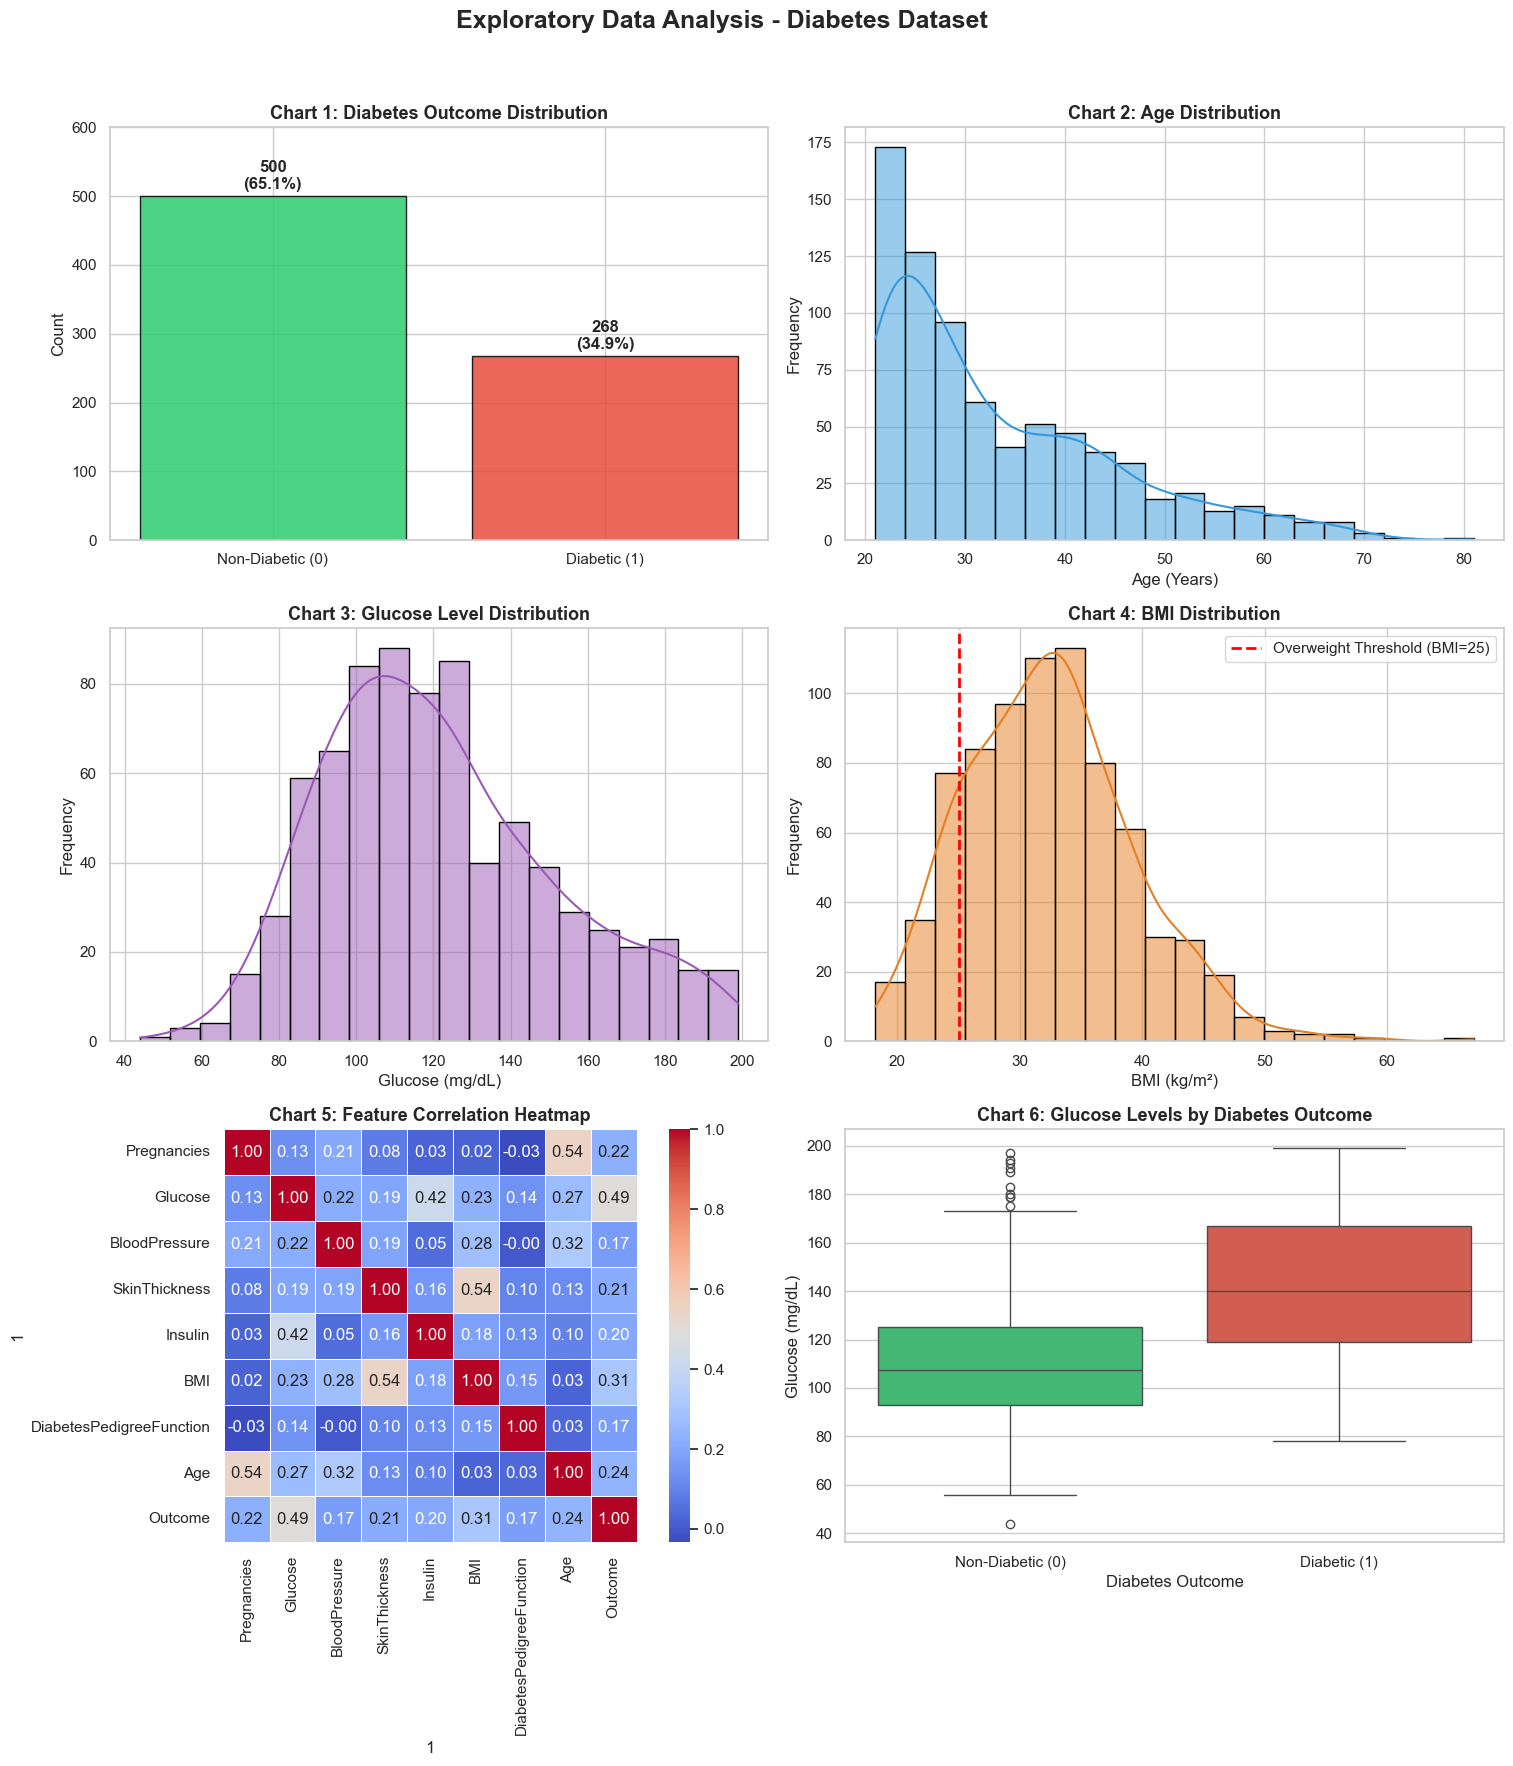

In [4]:
#Exploratory Data Analysis (EDA)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset
df = pd.read_csv('diabetes.csv', header=None)
df = df.iloc[1:].copy()
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)
df = df.apply(pd.to_numeric)

# 2. Data Cleaning: Replace impossible 0s with NaN and impute with median
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

for col in cols_with_zeros:
    col_median = df[col].median()
    df[col] = df[col].fillna(col_median)

# 3. Visualization Setup
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Exploratory Data Analysis - Diabetes Dataset', fontsize=18, fontweight='bold', y=0.98)

# Chart 1: Diabetes Distribution
ax1 = axes[0, 0]
outcome_counts = df['Outcome'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = ax1.bar(['Non-Diabetic (0)', 'Diabetic (1)'], outcome_counts.values, color=colors, edgecolor='black', alpha=0.85)
ax1.set_title('Chart 1: Diabetes Outcome Distribution', fontsize=13, fontweight='bold')
ax1.set_ylabel('Count')
for bar, count in zip(bars, outcome_counts.values):
    pct = (count / len(df)) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{count}\n({pct:.1f}%)', ha='center', fontweight='bold')
ax1.set_ylim(0, 600)

# Chart 2: Age Distribution
ax2 = axes[0, 1]
sns.histplot(df['Age'], kde=True, ax=ax2, color='#3498db', bins=20, edgecolor='black')
ax2.set_title('Chart 2: Age Distribution', fontsize=13, fontweight='bold')
ax2.set_xlabel('Age (Years)')
ax2.set_ylabel('Frequency')

# Chart 3: Glucose Distribution
ax3 = axes[1, 0]
sns.histplot(df['Glucose'], kde=True, ax=ax3, color='#9b59b6', bins=20, edgecolor='black')
ax3.set_title('Chart 3: Glucose Level Distribution', fontsize=13, fontweight='bold')
ax3.set_xlabel('Glucose (mg/dL)')
ax3.set_ylabel('Frequency')

# Chart 4: BMI Distribution
ax4 = axes[1, 1]
sns.histplot(df['BMI'], kde=True, ax=ax4, color='#e67e22', bins=20, edgecolor='black')
ax4.axvline(25, color='red', linestyle='--', linewidth=2, label='Overweight Threshold (BMI=25)')
ax4.set_title('Chart 4: BMI Distribution', fontsize=13, fontweight='bold')
ax4.set_xlabel('BMI (kg/m²)')
ax4.set_ylabel('Frequency')
ax4.legend(loc='upper right')

# Chart 5: Correlation Heatmap
ax5 = axes[2, 0]
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax5, cbar=True, square=True, linewidths=0.5)
ax5.set_title('Chart 5: Feature Correlation Heatmap', fontsize=13, fontweight='bold')

# Chart 6: Boxplot Glucose vs Outcome
ax6 = axes[2, 1]
sns.boxplot(x='Outcome', y='Glucose', data=df, ax=ax6, palette=['#2ecc71', '#e74c3c'])
ax6.set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])
ax6.set_title('Chart 6: Glucose Levels by Diabetes Outcome', fontsize=13, fontweight='bold')
ax6.set_xlabel('Diabetes Outcome')
ax6.set_ylabel('Glucose (mg/dL)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Chart 1: Diabetes Distribution
Is the dataset balanced?
No, the dataset is imbalanced.

Which class appears more often?
The Non-Diabetic class (0) appears significantly more often, representing 65.1% (500 instances) of the dataset compared to 34.9% (268 instances) for the Diabetic class (1).

Chart 2: Age Distribution
Which age group appears most?
The 21–25 age group appears most frequently, with the peak mode at 22 years old.

Is the distribution symmetric?
No, the distribution is not symmetric; it is strongly right-skewed (skewness = 1.13), with most patients concentrated under 30 years old.

Chart 3: Glucose Distribution
Are glucose values normally distributed?
Approximately, but it exhibits a slight right skew (skewness = 0.54) with a secondary peak corresponding to higher glucose levels among diabetic patients.

Are there outliers?
Yes, there are mild outliers on both ends, such as low glucose readings near 44 mg/dL and elevated levels approaching 199 mg/dL.

Chart 4: BMI Distribution
Are most patients overweight?
Yes, 86.2% of patients in the dataset have a BMI of 25.0 or higher, classifying them as overweight or obese.

Are there extreme values?
Yes, there are extreme upper values reaching up to 67.1 kg/m 
2
  (class III severe obesity).

Chart 5: Correlation Heatmap
Which feature has the strongest correlation with Outcome?
Glucose has the strongest positive correlation with Outcome (r=0.49).

Which two features are highly correlated?
The highest feature-to-feature correlations are:

Pregnancies & Age (r=0.54)

SkinThickness & BMI (r=0.54)

Chart 6: Boxplot (Glucose vs Outcome)
Do diabetic patients generally have higher glucose levels?
Yes, diabetic patients (Outcome = 1) have a substantially higher median glucose level (140.0 mg/dL) compared to non-diabetic patients (107.5 mg/dL), with the overall interquartile range shifted significantly upward.

In [5]:
#Prepare the Data

# 1. Separate Features (X) by dropping the target column 'Outcome'
X = df.drop(columns=['Outcome'])

# 2. Separate Target (y) using the 'Outcome' column
y = df['Outcome']

# Display shapes to verify separation
print(f"Features (X) Shape: {X.shape}")  # (768, 8)
print(f"Target (y) Shape: {y.shape}")      # (768,)

Features (X) Shape: (768, 8)
Target (y) Shape: (768,)


In [6]:
# Split the Dataset
from sklearn.model_selection import train_test_split

# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Display set sizes
print(f"Training Features (X_train): {X_train.shape}")  # (614, 8)
print(f"Testing Features (X_test):   {X_test.shape}")   # (154, 8)
print(f"Training Target (y_train):   {y_train.shape}")   # (614,)
print(f"Testing Target (y_test):     {y_test.shape}")   # (154,)

Training Features (X_train): (614, 8)
Testing Features (X_test):   (154, 8)
Training Target (y_train):   (614,)
Testing Target (y_test):     (154,)


In [8]:
#Feature Scaling


from sklearn.preprocessing import StandardScaler

# 1. Instantiate StandardScaler
scaler = StandardScaler()

# 2. Fit and transform the training set
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the testing set using the training parameters
X_test_scaled = scaler.transform(X_test)

# Optional: Convert back to DataFrame for easier inspection
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

In [9]:
#Train Multiple Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# --- Model 1: Logistic Regression ---
# Requires scaled features
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# --- Model 2: Decision Tree ---
# Tree models are scale-invariant; unscaled or scaled features both work
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# --- Model 3: Random Forest ---
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# --- Model 4: Support Vector Machine (SVM) ---
# Requires scaled features
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)

# --- Model 5: K-Nearest Neighbors (KNN) ---
# Distance-based algorithm; requires scaled features
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

print("All 5 models trained successfully!")

All 5 models trained successfully!


In [10]:
#Model Evaluation
#Evaluate every model using
#Accuracy
#Precision
#Recall
#F1 Score
#Confusion Matrix
#Classification Report
#Create a comparison table.
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    classification_report
)
import pandas as pd

# Define models and scaling requirements
models = {
    'Logistic Regression': (lr_model, True),
    'Decision Tree': (dt_model, False),
    'Random Forest': (rf_model, False),
    'Support Vector Machine': (svm_model, True),
    'K-Nearest Neighbors': (knn_model, True)
}

results = []

# Evaluate each model
for name, (model, uses_scaled) in models.items():
    X_test_data = X_test_scaled if uses_scaled else X_test
    y_pred = model.predict(X_test_data)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'Confusion Matrix': cm,
        'Classification Report': cr
    })

# Print detailed evaluations
for res in results:
    print(f"==========================================")
    print(f" Model: {res['Model']}")
    print(f"==========================================")
    print(f"Accuracy:  {res['Accuracy']:.4f}")
    print(f"Precision: {res['Precision']:.4f}")
    print(f"Recall:    {res['Recall']:.4f}")
    print(f"F1 Score:  {res['F1 Score']:.4f}")
    print("\nConfusion Matrix:")
    print(res['Confusion Matrix'])
    print("\nClassification Report:")
    print(res['Classification Report'])
    print("\n")

 Model: Logistic Regression
Accuracy:  0.7078
Precision: 0.6000
Recall:    0.5000
F1 Score:  0.5455

Confusion Matrix:
[[82 18]
 [27 27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



 Model: Decision Tree
Accuracy:  0.6818
Precision: 0.5532
Recall:    0.4815
F1 Score:  0.5149

Confusion Matrix:
[[79 21]
 [28 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154



 Model: Random Forest
Ac

Answer the following questions.
1. Which model achieved the highest Accuracy?
   Random Forest achieved the highest accuracy at 77.92% ($0.7792$).
2. Which model achieved the highest Recall?
   K-Nearest Neighbors (KNN) achieved the highest recall at 61.11% ($0.6111$).
3. Which model achieved the highest F1 Score?
   Random Forest achieved the highest F1 score at 65.31% ($0.6531$).
4. Which model would you recommend?
   Explain your answer.Recommendation: Random Forest Classifier (or a recall-tuned     Random Forest).
   Explanation:
Best Overall Predictive Balance: Random Forest outperforms all other models across Accuracy (77.92%), Precision (72.73%), and F1 Score (65.31%). The high F1 score demonstrates that it achieves the best harmonic balance between avoiding false alarms and capturing true positive cases.

Clinical Significance of Recall vs. Precision: In medical diagnostics (such as predicting diabetes), Recall is critical because a False Negative (failing to identify a diabetic patient) carries a much higher medical risk than a False Positive (flagging a healthy patient for follow-up testing).

While KNN achieves a slightly higher default recall (61.11% vs. 59.26%), it comes at the cost of significantly lower overall precision (66.00% vs. 72.73%) and lower overall accuracy.

Optimizing Random Forest for Medical Deployment: Since Random Forest outputs class probabilities (predict_proba), you can lower its decision threshold (e.g., from 0.50 down to 0.35 or 0.40). This increases its Recall well above 70–80% while retaining superior feature ensemble stability compared to single KNN or Decision Tree models.

   

In [12]:
#Save the Best Model
import os
import json
import joblib

# Create 'models' directory if it doesn't already exist
os.makedirs('models', exist_ok=True)

# 1. Save the best model (Random Forest) as a .pkl file
joblib.dump(rf_model, 'models/best_model.pkl')

# 2. Extract and save feature names as a JSON file
feature_info = {
    'feature_names': list(X.columns),
    'num_features': len(X.columns)
}

with open('models/feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=4)

print("Best model and feature metadata saved successfully!")

Best model and feature metadata saved successfully!


#Interpretation Questions
Question 1: What is Classification?
Classification is a supervised machine learning task where the model learns to assign discrete categorical labels to input data points based on their features. Unlike regression, which predicts continuous numerical values (e.g., house prices), classification predicts distinct classes or groups (e.g., Spam vs. Not Spam, Fraudulent vs. Legitimate).

Question 2: Why is this a binary classification problem?This task is a binary classification problem because the target variable (Outcome) has exactly two possible categories or classes:0: Non-Diabetic (Negative class)   1: Diabetic (Positive class)   Since the output is restricted to two mutually exclusive choices, it fits the definition of binary classification.

Question 3: Explain Accuracy, Precision, Recall, and F1 ScoreAccuracy: The percentage of overall correct predictions (both positive and negative) out of all total predictions made.$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

Precision: The percentage of correctly predicted positive cases out of all cases that the model flagged as positive. It measures prediction exactness.$$\text{Precision} = \frac{TP}{TP + FP}$$

Recall (Sensitivity): The percentage of actual positive cases that the model correctly identified. It measures completeness in capturing true positives.$$\text{Recall} = \frac{TP}{TP + FN}$$

F1 Score: The harmonic mean of Precision and Recall. It provides a balanced metric when there is an uneven class distribution or when you need to balance Precision and Recall simultaneously.$$\text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Question 4: What is a False Positive? Give a real-life example.
A False Positive (Type I Error) occurs when a model incorrectly predicts a positive outcome for a sample that is actually negative.

Real-Life Example: A medical diagnostic test flags a healthy individual as having diabetes when they actually do not have the condition.

Consequence: The individual may experience temporary psychological stress and undergo unnecessary follow-up blood tests before discovering they are healthy.

Question 5: What is a False Negative? Give a real-life example.
A False Negative (Type II Error) occurs when a model incorrectly predicts a negative outcome for a sample that is actually positive.

Real-Life Example: A medical diagnostic test marks a diabetic patient as non-diabetic (healthy), sending them home without treatment.

Consequence: The patient leaves untreated, leading to unmonitored blood glucose levels, worsening medical conditions, and serious potential complications (e.g., organ damage or cardiovascular issues).

Question 6: Which error is more dangerous in diabetes prediction? Why?
A False Negative is significantly more dangerous in medical contexts like diabetes prediction.

Reasoning:

If a patient receives a False Positive, the worst outcome is usually anxiety and additional confirmation tests, which quickly reveal the error.

If a patient receives a False Negative, they believe they are healthy and miss critical medical interventions, lifestyle adjustments, and medication. Over time, untreated diabetes can lead to severe long-term complications such as kidney failure, nerve damage, vision loss, or stroke.

Question 7: Why should we save the trained model?
Saving a trained model (e.g., as best_model.pkl) is essential because:

Avoids Retraining Overhead: You do not need to re-run time-consuming data preprocessing and model training scripts every time you want to make a new prediction.

Deployment Readiness: It allows the model to be loaded into production environments, web applications, or REST APIs (like Flask or FastAPI) to make instant predictions on live user data.

Reproducibility: It ensures that the exact fitted parameters, weights, and decision rules evaluated during testing are preserved for production use.

Question 8: Why should we save the feature metadata?
Saving feature metadata (e.g., as feature_info.json) is crucial because:

Ensures Feature Alignment: Machine learning models rely on receiving input features in the exact same order and with the exact same names as the features used during training.

Prevents Input Validation Errors: It allows web applications or client interfaces to validate incoming user requests before feeding them into the model, ensuring missing or extra columns are caught immediately.

Pipeline Consistency: If you apply feature engineering or scaling in production, feature metadata guarantees that raw incoming data maps cleanly to the required input structure.